In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import matplotlib.ticker as mtick
import warnings 
warnings.filterwarnings('ignore')

In [4]:
#.Read Source
df = pd.read_csv('D:/kaggle/datasets/ev_market_master.csv')

In [39]:
#.Describe it
df.head()

,country,brand,drivetrain_type,year,month,units_sold,frequency,source,trend_byd,trend_ev_charging,...,total_chargers_cumulative,gasoline_price_usd_per_liter,units_sold_lag1,units_sold_lag3,units_sold_lag12,units_sold_rolling3,units_sold_yoy_growth,quarter,date,date_str
0,China,BYD,BEV+PHEV,2020,1,24840,monthly_est,brand_reports,2.75,NaN,...,784000.0,0.78,NaN,NaN,NaN,24840.0,NaN,1,01-01-2020,2020-01
1,China,BYD,BEV+PHEV,2020,2,24840,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.78,24840.0,NaN,NaN,24840.0,NaN,1,01-02-2020,2020-02
2,China,BYD,BEV+PHEV,2020,3,24840,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.78,24840.0,NaN,NaN,24840.0,NaN,1,01-03-2020,2020-03
3,China,BYD,BEV+PHEV,2020,4,29880,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.80,24840.0,24840.0,NaN,26520.0,NaN,2,01-04-2020,2020-04
4,China,BYD,BEV+PHEV,2020,5,29880,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.80,29880.0,24840.0,NaN,28200.0,NaN,2,01-05-2020,2020-05


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       420 non-null    object 
 1   brand                         420 non-null    object 
 2   drivetrain_type               420 non-null    object 
 3   year                          420 non-null    int64  
 4   month                         420 non-null    int64  
 5   units_sold                    420 non-null    int64  
 6   frequency                     420 non-null    object 
 7   source                        420 non-null    object 
 8   trend_byd                     420 non-null    float64
 9   trend_ev_charging             409 non-null    float64
 10  trend_tesla                   420 non-null    float64
 11  trend_electric_car            420 non-null    float64
 12  trend_electric_vehicle        409 non-null    float64
 13  slow_

In [9]:
df.columns.to_list()

['country',
 'brand',
 'drivetrain_type',
 'year',
 'month',
 'units_sold',
 'frequency',
 'source',
 'trend_byd',
 'trend_ev_charging',
 'trend_tesla',
 'trend_electric_car',
 'trend_electric_vehicle',
 'slow_chargers_cumulative',
 'fast_chargers_cumulative',
 'total_chargers_cumulative',
 'gasoline_price_usd_per_liter',
 'units_sold_lag1',
 'units_sold_lag3',
 'units_sold_lag12',
 'units_sold_rolling3',
 'units_sold_yoy_growth',
 'quarter',
 'date',
 'date_str']

In [10]:
df.isnull().sum()

country                           0
brand                             0
drivetrain_type                   0
year                              0
month                             0
units_sold                        0
frequency                         0
source                            0
trend_byd                         0
trend_ev_charging                11
trend_tesla                       0
trend_electric_car                0
trend_electric_vehicle           11
slow_chargers_cumulative         24
fast_chargers_cumulative         24
total_chargers_cumulative        24
gasoline_price_usd_per_liter      0
units_sold_lag1                   9
units_sold_lag3                  27
units_sold_lag12                108
units_sold_rolling3               0
units_sold_yoy_growth           108
quarter                           0
date                              0
date_str                          0
dtype: int64

In [22]:
#derive chart for sales by country.
conuntry_wise_ev_sales = df.groupby(['country', 'year'])['units_sold'].sum().reset_index()
conuntry_wise_ev_sales['unit_sold_in_millions'] = (conuntry_wise_ev_sales['units_sold'] / 1_000_000).round(2)
conuntry_wise_ev_sales

,country,year,units_sold,unit_sold_in_millions
0,China,2020,469089,0.47
1,China,2021,1785279,1.79
2,China,2022,5259168,5.26
3,China,2023,6885516,6.89
4,France,2019,61608,0.06
5,France,2020,185664,0.19
6,France,2021,297096,0.30
7,France,2022,371088,0.37
8,France,2023,476448,0.48
9,Germany,2021,203997,0.20


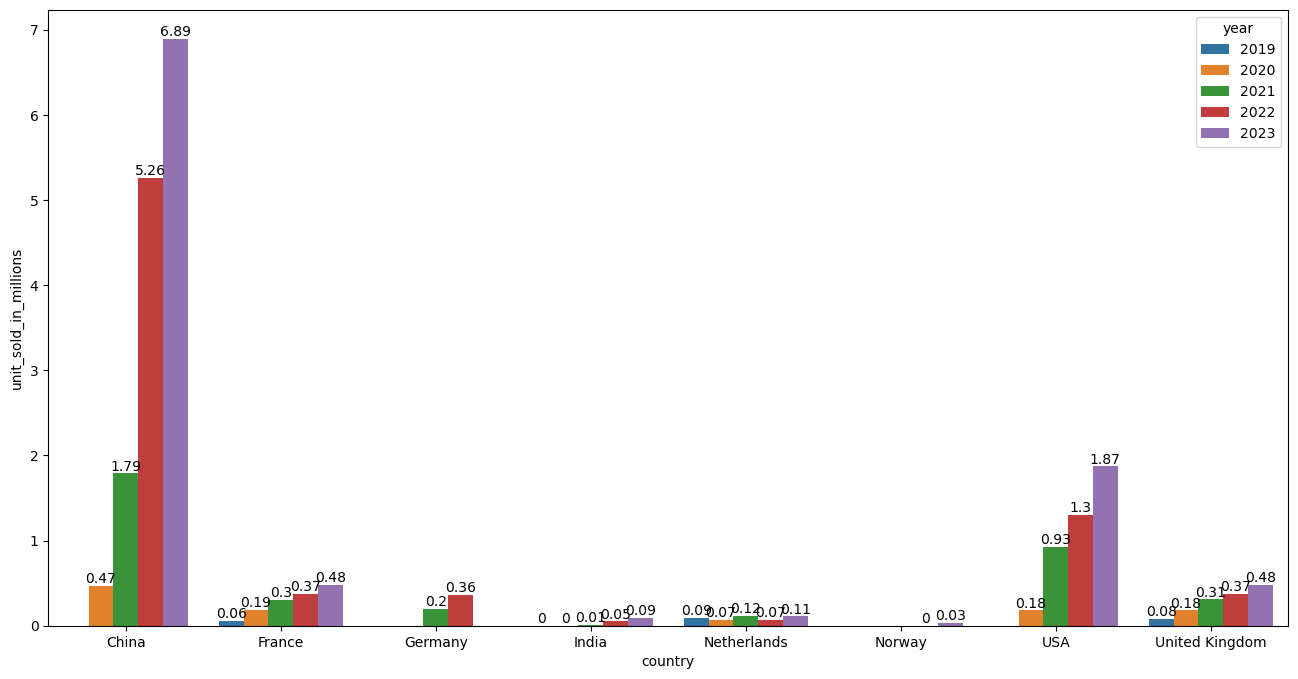

In [27]:
plt.figure(figsize=(16, 8))  
ax = sns.barplot(x='country',y='unit_sold_in_millions', hue='year',data=conuntry_wise_ev_sales,palette=sns.color_palette("tab10"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [32]:
#derive chart for sales by country.
brand_wise_ev_sales = df.groupby(['brand', 'year'])['units_sold'].sum().reset_index()
brand_wise_ev_sales['unit_sold_in_millions'] = (brand_wise_ev_sales['units_sold'] / 1_000_000).round(2)
brand_wise_ev_sales=  brand_wise_ev_sales[brand_wise_ev_sales['brand'] != 'All']
brand_wise_ev_sales

,brand,year,units_sold,unit_sold_in_millions
5,BYD,2020,469089,0.47
6,BYD,2021,1298622,1.30
7,BYD,2022,4609980,4.61
8,BYD,2023,6347904,6.35
9,Tesla,2020,180336,0.18
10,Tesla,2021,1418139,1.42
11,Tesla,2022,1955535,1.96
12,Tesla,2023,2436726,2.44
13,VW,2021,203997,0.20
14,VW,2022,355896,0.36


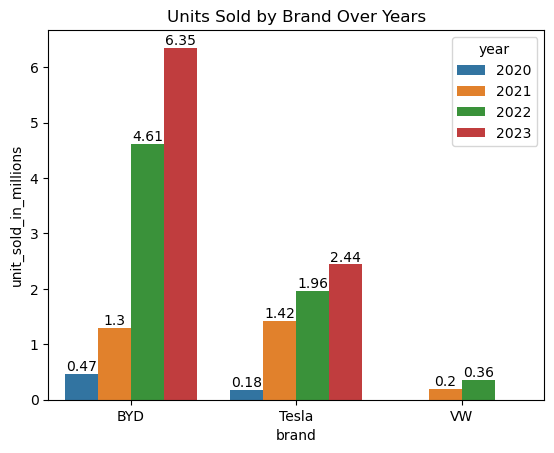

In [36]:
ax = sns.barplot(x='brand',y='unit_sold_in_millions', hue='year',data=brand_wise_ev_sales,palette=sns.color_palette("tab10"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Units Sold by Brand Over Years")    
plt.show()

In [38]:
df.corr(numeric_only=True)

,year,month,units_sold,trend_byd,trend_ev_charging,trend_tesla,trend_electric_car,trend_electric_vehicle,slow_chargers_cumulative,fast_chargers_cumulative,total_chargers_cumulative,gasoline_price_usd_per_liter,units_sold_lag1,units_sold_lag3,units_sold_lag12,units_sold_rolling3,units_sold_yoy_growth,quarter
year,1.000000e+00,-1.186480e-14,0.311908,0.531732,0.265758,0.573094,0.118786,-0.072981,2.917466e-01,3.147844e-01,2.974850e-01,0.295739,0.316402,0.330214,0.326082,0.321519,0.050476,-1.247788e-14
month,-1.186480e-14,1.000000e+00,0.101923,0.051503,0.073752,-0.077866,0.016308,-0.011640,-3.437962e-16,-3.224208e-16,-3.286511e-16,0.045513,0.078813,0.011708,0.130951,0.088795,-0.103878,9.716254e-01
units_sold,3.119080e-01,1.019231e-01,1.000000,0.483065,-0.153498,0.206712,-0.142185,-0.211951,6.455606e-01,6.571940e-01,6.490327e-01,-0.210290,0.983132,0.950846,0.892763,0.991276,-0.013621,1.048996e-01
trend_byd,5.317325e-01,5.150326e-02,0.483065,1.000000,-0.236070,0.234753,-0.120053,-0.229917,7.018221e-01,7.257872e-01,7.082508e-01,0.014797,0.491191,0.501078,0.502242,0.487817,-0.057922,5.449378e-02
trend_ev_charging,2.657577e-01,7.375194e-02,-0.153498,-0.236070,1.000000,0.348079,0.576576,0.558884,-4.501734e-01,-4.319335e-01,-4.462752e-01,0.191225,-0.154419,-0.154758,-0.168175,-0.149879,-0.199362,7.979866e-02
trend_tesla,5.730940e-01,-7.786621e-02,0.206712,0.234753,0.348079,1.000000,0.004848,-0.091493,1.246499e-01,1.270519e-01,1.253569e-01,0.292309,0.209506,0.216597,0.136765,0.213132,-0.046438,-7.011538e-02
trend_electric_car,1.187857e-01,1.630838e-02,-0.142185,-0.120053,0.576576,0.004848,1.000000,0.498845,-2.686139e-01,-2.353379e-01,-2.611208e-01,-0.096114,-0.146608,-0.148393,-0.147459,-0.142846,-0.071325,1.684652e-02
trend_electric_vehicle,-7.298097e-02,-1.164021e-02,-0.211951,-0.229917,0.558884,-0.091493,0.498845,1.000000,-4.675350e-01,-4.328794e-01,-4.597985e-01,-0.293034,-0.213755,-0.209987,-0.189683,-0.209841,-0.093799,-1.141776e-02
slow_chargers_cumulative,2.917466e-01,-3.437962e-16,0.645561,0.701822,-0.450173,0.124650,-0.268614,-0.467535,1.000000e+00,9.935833e-01,9.996483e-01,-0.331193,0.650143,0.664198,0.621015,0.654716,-0.087477,-4.984294e-16
fast_chargers_cumulative,3.147844e-01,-3.224208e-16,0.657194,0.725787,-0.431933,0.127052,-0.235338,-0.432879,9.935833e-01,1.000000e+00,9.962334e-01,-0.316988,0.662692,0.679144,0.631752,0.668267,-0.083733,-4.500249e-16
